# 01 — Real Numbers

**Topic 1 of the math journey.** Goal: understand *what numbers really are*, how they
are built one layer on top of another, and which rules (axioms) they obey. This is the
ground floor of all later mathematics, so we go slowly and prove things.

## Intuition first
Think of a long straight **line** with a point marked `0`. Every real number is one
point on this line:
- to the right = positive, to the left = negative,
- the further from 0, the bigger the size of the number.

The amazing fact: this line has **no holes**. Every position you can point to is a real
number. Building up to that idea is the whole story of this lesson.

```
      -3   -2   -1    0    1    2    3
  <----+----+----+----+----+----+----+---->
                      ^
                  the origin
```


## 1. The four number systems

We build numbers in layers. Each layer sits *inside* the next.

- **Natural numbers** $\mathbb{N} = \{0, 1, 2, 3, \dots\}$ — for counting.
- **Integers** $\mathbb{Z} = \{\dots, -2, -1, 0, 1, 2, \dots\}$ — add negatives, so
  subtraction always works.
- **Rational numbers** $\mathbb{Q} = \left\{ \dfrac{p}{q} : p,q \in \mathbb{Z},\ q \neq 0 \right\}$
  — fractions, so division (except by 0) always works.
- **Real numbers** $\mathbb{R}$ — every point on the number line, including numbers that
  are *not* fractions, such as $\sqrt{2}$ and $\pi$.

The chain of inclusions:
$$ \mathbb{N} \subset \mathbb{Z} \subset \mathbb{Q} \subset \mathbb{R}. $$

A real number that is **not** rational is called **irrational**. So $\mathbb{R}$ splits
into two parts: rationals and irrationals.

*New symbols:* $\in$ means "is an element of"; $\subset$ means "is a subset of";
$\neq$ means "not equal".


In [1]:
import sympy as sp            # sympy = "symbolic python": it does exact math, not rounded decimals

# sympy can tell which set a number belongs to.
# Rational(3, 4) is the exact fraction 3/4 (NOT the rounded float 0.75).
x = sp.Rational(3, 4)
print("3/4 is rational? ", x.is_rational)   # .is_rational asks: is this a fraction p/q?
print("3/4 is integer?  ", x.is_integer)

# sqrt(2) is a real number but NOT a fraction.
r = sp.sqrt(2)
print("sqrt(2) is rational?", r.is_rational) # False  -> it is irrational
print("sqrt(2) is real?    ", r.is_real)     # True
print("sqrt(2) approx:     ", sp.N(r, 12))   # sp.N(..., 12) = numeric value with 12 digits


3/4 is rational?  True
3/4 is integer?   False
sqrt(2) is rational? False
sqrt(2) is real?     True
sqrt(2) approx:      1.41421356237


## 2. Decimal expansions: a test for "rational vs irrational"

Every real number can be written as a decimal. There is a clean rule:

> **Theorem (decimal test).** A real number is **rational** *if and only if* its decimal
> expansion **terminates** (stops) or **eventually repeats** a block forever.

Examples: $\tfrac14 = 0.25$ (terminates), $\tfrac13 = 0.3333\dots = 0.\overline{3}$
(repeats). But $\pi = 3.14159\dots$ never repeats, so $\pi$ is irrational.

**Proof (⇒ direction: rational gives terminating or repeating).**
Take a fraction $p/q$ and do long division. At each step the remainder is one of the
numbers $0, 1, 2, \dots, q-1$ — only $q$ possibilities. After at most $q$ steps a
remainder must come back (this is the *pigeonhole principle*: more steps than boxes
means a box repeats). If the remainder ever becomes $0$, the decimal **terminates**.
Otherwise a remainder repeats, and from that point the digits **repeat** in a block. ∎

**Proof (⇐ direction: a repeating decimal is a fraction).**
Let $x = 0.\overline{d_1 d_2 \dots d_k}$ be a block of $k$ digits repeating. Multiply by
$10^k$ to shift one whole block: $10^k x = D.\overline{d_1\dots d_k}$, where $D$ is the
integer made of the digits. Subtract: $10^k x - x = D$, so $x = \dfrac{D}{10^k - 1}$,
which is a fraction of integers, i.e. rational. (A terminating decimal is the special
case where the repeating block is "$0$".) ∎


In [2]:
from fractions import Fraction   # Fraction = exact rational numbers from Python's core library

# Show the repeating decimal of 1/7 by doing long division by hand (digit by digit).
def long_division_digits(p, q, n_digits=12):
    digits = []
    p = p % q                       # work with the fractional part only
    for _ in range(n_digits):
        p *= 10                     # bring down a zero, like in school long division
        digits.append(p // q)       # // is integer division -> the next decimal digit
        p = p % q                   # % is the remainder that we carry to the next step
    return digits

print("1/7  ->", long_division_digits(1, 7))   # 142857 142857 ... a repeating block
print("1/4  ->", long_division_digits(1, 4))   # 25 then all zeros -> it terminates

# The reverse direction: turn the repeating decimal 0.(36) back into a fraction.
# x = 0.363636...; 100x - x = 36  ->  x = 36/99
x = Fraction(36, 99)
print("0.(36) as a fraction:", x)              # Fraction auto-reduces to 4/11


1/7  -> [1, 4, 2, 8, 5, 7, 1, 4, 2, 8, 5, 7]
1/4  -> [2, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
0.(36) as a fraction: 4/11


## 3. The field axioms: the rules of $+$ and $\times$

$\mathbb{R}$ with addition and multiplication is a **field**. That word just means: the
following rules always hold. For all real $a, b, c$:

| Rule | Addition | Multiplication |
|---|---|---|
| **Commutative** | $a+b = b+a$ | $ab = ba$ |
| **Associative** | $(a+b)+c = a+(b+c)$ | $(ab)c = a(bc)$ |
| **Identity** | $a+0 = a$ | $a\cdot 1 = a$ |
| **Inverse** | $a+(-a)=0$ | $a\cdot a^{-1}=1$ if $a\neq 0$ |
| **Distributive** | \multicolumn{2}{c}{$a(b+c) = ab + ac$} |

Everything you "already know" about algebra (moving terms, cancelling, expanding
brackets) is *derived* from these few rules. Let us prove one small but famous result.

**Theorem.** For every real $a$, we have $a \cdot 0 = 0$.

**Proof.** Start from $0 + 0 = 0$ (identity). Multiply both sides by $a$ and use the
distributive rule:
$$ a\cdot 0 = a\cdot(0+0) = a\cdot 0 + a\cdot 0. $$
Now add $-(a\cdot 0)$ (the additive inverse) to both sides:
$$ a\cdot 0 + \big(-(a\cdot 0)\big) = \big(a\cdot 0 + a\cdot 0\big) + \big(-(a\cdot 0)\big). $$
The left side is $0$. The right side, by associativity, is
$a\cdot 0 + \big(a\cdot 0 - (a\cdot 0)\big) = a\cdot 0 + 0 = a\cdot 0$. Hence
$0 = a\cdot 0$. ∎


In [3]:
import sympy as sp
a, b, c = sp.symbols('a b c')        # symbols = letters we do exact algebra with

# sympy can CHECK an identity: sp.simplify(LHS - RHS) == 0 means "they are always equal".
distributive = sp.simplify(a*(b + c) - (a*b + a*c))
print("a(b+c) - (ab+ac) simplifies to:", distributive, " -> rule holds")

commutative = sp.simplify(a*b - b*a)
print("ab - ba simplifies to:        ", commutative, " -> rule holds")

# The proved theorem a*0 = 0:
print("a * 0 =", sp.simplify(a*0))


a(b+c) - (ab+ac) simplifies to: 0  -> rule holds
ab - ba simplifies to:         0  -> rule holds
a * 0 = 0


## 4. Order, absolute value, and intervals

$\mathbb{R}$ is **ordered**: for any two reals exactly one of $a<b$, $a=b$, $a>b$ holds,
and the order plays well with the operations:
- if $a<b$ then $a+c<b+c$,
- if $a<b$ and $c>0$ then $ac<bc$ (multiplying by a **positive** number keeps the order).

**Absolute value** measures distance from $0$:
$$ |a| = \begin{cases} a & \text{if } a \ge 0, \\ -a & \text{if } a < 0. \end{cases} $$
So $|a-b|$ is the distance between $a$ and $b$ on the line.

**Theorem (triangle inequality).** For all real $a,b$: $\;|a+b| \le |a| + |b|$.

**Proof.** For any real $x$ we have $-|x| \le x \le |x|$ (check both signs of $x$). Apply
this to $a$ and to $b$ and add the two double-inequalities:
$$ -(|a|+|b|) \le a+b \le |a|+|b|. $$
Saying $-M \le y \le M$ is the same as $|y| \le M$. With $y=a+b$ and $M=|a|+|b|$ we get
$|a+b| \le |a|+|b|$. ∎

**Intervals** are connected pieces of the line. With $a<b$:
$[a,b]=\{x: a\le x\le b\}$ (endpoints included), $(a,b)=\{x: a<x<b\}$ (excluded), and
half-open mixes like $[a,b)$.


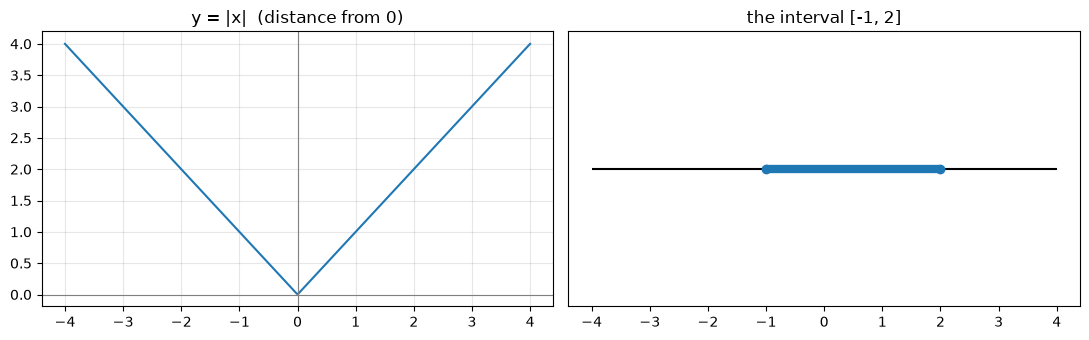

|a+b| <= |a|+|b| for all samples? True


In [4]:
import numpy as np                 # numpy = fast arrays of numbers, good for plotting
import matplotlib.pyplot as plt      # matplotlib = drawing graphs

# --- Picture 1: the absolute value function y = |x| (a V-shape) ---
x = np.linspace(-4, 4, 400)          # 400 evenly spaced x-values from -4 to 4
y = np.abs(x)                        # np.abs computes |x| for every value at once

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
ax1.plot(x, y)
ax1.set_title("y = |x|  (distance from 0)")
ax1.axhline(0, color="gray", lw=0.8); ax1.axvline(0, color="gray", lw=0.8)
ax1.grid(True, alpha=0.3)

# --- Picture 2: the closed interval [-1, 2] drawn on the number line ---
ax2.hlines(0, -4, 4, color="black")                  # the number line itself
ax2.hlines(0, -1, 2, color="tab:blue", lw=6)         # the interval [-1, 2] as a thick bar
ax2.plot([-1, 2], [0, 0], "o", color="tab:blue")     # filled dots = endpoints INCLUDED
ax2.set_title("the interval [-1, 2]")
ax2.set_ylim(-1, 1); ax2.set_yticks([])
plt.tight_layout(); plt.show()

# Check the triangle inequality on random numbers (a numeric sanity test, not a proof).
rng = np.random.default_rng(0)
a, b = rng.uniform(-10, 10, 5), rng.uniform(-10, 10, 5)
print("|a+b| <= |a|+|b| for all samples?", np.all(np.abs(a+b) <= np.abs(a)+np.abs(b)))


## 5. Why $\sqrt{2}$ is irrational (a complete proof)

The Greeks discovered that the diagonal of a unit square has length $\sqrt 2$, and that
this length is **not** a fraction. This was a shock. Here is the proof.

**Theorem.** $\sqrt{2}$ is irrational.

**Proof (by contradiction).** Suppose, for contradiction, that $\sqrt 2$ *is* rational.
Then we can write
$$ \sqrt{2} = \frac{p}{q} $$
as a fraction in **lowest terms**, meaning $p$ and $q$ are integers with no common factor
(so $\gcd(p,q)=1$). Square both sides:
$$ 2 = \frac{p^2}{q^2} \quad\Longrightarrow\quad p^2 = 2q^2. $$
So $p^2$ is even. But the square of an odd number is odd, so $p$ itself must be **even**;
write $p = 2k$. Substitute:
$$ (2k)^2 = 2q^2 \;\Longrightarrow\; 4k^2 = 2q^2 \;\Longrightarrow\; q^2 = 2k^2. $$
By the same argument $q^2$ is even, so $q$ is **even** too. But now $p$ and $q$ are both
even — they share the factor $2$ — which contradicts "lowest terms". The assumption was
impossible. Therefore $\sqrt{2}$ is irrational. ∎

The same idea shows $\sqrt{n}$ is irrational whenever $n$ is not a perfect square.


In [5]:
import sympy as sp

# sympy KNOWS sqrt(2) is irrational (exact symbolic fact):
print("sqrt(2).is_rational =", sp.sqrt(2).is_rational)   # False

# A numeric hint of the proof: no small fraction p/q equals sqrt(2) exactly.
import math
best = None
target = math.sqrt(2)
for q in range(1, 2000):
    p = round(target * q)              # the best integer p for this q
    err = abs(target - p/q)            # how far p/q is from sqrt(2)
    if best is None or err < best[0]:
        best = (err, p, q)
print(f"closest fraction with q<2000: {best[1]}/{best[2]}, error={best[0]:.2e} (never 0)")


sqrt(2).is_rational = False
closest fraction with q<2000: 1393/985, error=3.64e-07 (never 0)


## 6. Completeness: the line has no holes

This is the deep property that separates $\mathbb{R}$ from $\mathbb{Q}$.

**Definitions.** Let $S$ be a non-empty set of real numbers.
- A number $M$ is an **upper bound** of $S$ if $x \le M$ for every $x \in S$.
- A number $L$ is the **least upper bound** (or **supremum**, $\sup S$) if $L$ is an
  upper bound and *no smaller number* is an upper bound.

> **Completeness Axiom.** Every non-empty set of real numbers that has an upper bound
> has a least upper bound **in $\mathbb{R}$**.

Why this matters: take $S = \{ x \in \mathbb{Q} : x^2 < 2 \}$. Inside $\mathbb{Q}$ this
set has upper bounds (like $1.5$) but **no least one** — you can always find a smaller
rational bound, squeezing toward $\sqrt 2$, which is missing from $\mathbb{Q}$. So
$\mathbb{Q}$ has a "hole" at $\sqrt 2$. In $\mathbb{R}$ the hole is filled:
$\sup S = \sqrt 2$. Completeness is exactly the statement "no holes".

From completeness one can prove the **Archimedean property**: for any real $x$ there is a
natural number $n$ with $n > x$ (no real number is bigger than every integer). We use it
next.

**Theorem (rationals are dense).** Between any two reals $a<b$ there is a rational number.

**Proof.** Since $b-a>0$, the Archimedean property gives a natural number $n$ with
$n(b-a)>1$, i.e. $\tfrac1n < b-a$. Let $m = \lfloor na \rfloor + 1$ (the first integer
above $na$; here $\lfloor\cdot\rfloor$ is the floor = round down). Then $m>na$, so
$\tfrac{m}{n}>a$. Also $m \le na+1 < na + n(b-a) = nb$, so $\tfrac{m}{n}<b$. Hence
$a < \tfrac{m}{n} < b$, a rational strictly between them. ∎


In [6]:
from fractions import Fraction
import math

# Demonstrate density: build a rational strictly between two reals a < b,
# using exactly the construction from the proof.
def rational_between(a, b):
    n = 1
    while not (n * (b - a) > 1):     # find n with 1/n < b - a  (Archimedean step)
        n += 1
    m = math.floor(n * a) + 1        # first integer above n*a  (the floor + 1 step)
    return Fraction(m, n)

a, b = math.sqrt(2), math.sqrt(2) + 0.001   # two very close irrational-looking reals
r = rational_between(a, b)
print(f"a = {a:.6f}")
print(f"rational found: {r} = {float(r):.6f}")
print(f"b = {b:.6f}")
print("Is a < r < b ?", a < float(r) < b)

# Squeezing toward sqrt(2) from below with rationals whose square stays < 2:
import sympy as sp
print("sup{ x in Q : x^2 < 2 } should be sqrt(2) =", sp.N(sp.sqrt(2), 10))


a = 1.414214
rational found: 1416/1001 = 1.414585
b = 1.415214
Is a < r < b ? True
sup{ x in Q : x^2 < 2 } should be sqrt(2) = 1.414213562


## Summary — what you should now be able to say

1. The layers $\mathbb{N}\subset\mathbb{Z}\subset\mathbb{Q}\subset\mathbb{R}$ and *why*
   each new layer is needed (subtraction, division, filling holes).
2. The **decimal test** for rationality (terminating or repeating ⇔ rational).
3. The **field axioms** and how ordinary algebra is derived from them.
4. **Order**, **absolute value**, the **triangle inequality**, and intervals.
5. A full proof that **$\sqrt 2$ is irrational**.
6. **Completeness** (least upper bound) as the property that makes $\mathbb{R}$ a line
   with no holes, plus the **density** of $\mathbb{Q}$ in $\mathbb{R}$.


## Exercises (20)

Write your answers in the empty cells below each block. Try first — do not look up the
answer. Mix of "compute", "explain", and "prove". The last ones are proofs.

**A. Warm-up (compute / classify)**
1. Classify each as natural, integer, rational, or irrational: $-5,\ \tfrac{7}{2},\ \sqrt{9},\ \sqrt{3},\ 0,\ \pi$.
2. Write $0.75$ and $0.125$ as fractions in lowest terms.
3. Turn the repeating decimal $0.\overline{6}$ into a fraction. (Hint: $10x - x$.)
4. Turn $0.\overline{27}$ into a fraction.
5. Compute $|{-3}| + |5 - 9|$.

**B. Decimals & order**
6. Without a calculator, decide if $\tfrac{3}{8}$ has a terminating or repeating decimal, and explain why using its denominator.
7. Find any rational number strictly between $0.333$ and $\tfrac13$.
8. Write the set $\{x : |x-2| < 3\}$ as an interval.
9. Write the set $\{x : |x+1| \ge 4\}$ as a union of two intervals.
10. Order from smallest to largest: $\tfrac{22}{7},\ \pi,\ 3.14,\ \sqrt{10}$.

**C. Using the axioms (short explanations)**
11. Using only the field axioms, explain why $-(-a) = a$.
12. Show that if $ab = 0$ then $a=0$ or $b=0$. (Hint: if $a\neq 0$, multiply by $a^{-1}$.)
13. Explain why dividing by $0$ cannot be defined as a real number.
14. Give a counterexample to: "if $a<b$ then $ac<bc$" when $c$ is allowed to be negative.
15. Prove $|a| = |-a|$ for every real $a$.

**D. Proofs (raise the bar)**
16. Prove that the sum of a rational and an irrational number is irrational.
17. Prove that $\sqrt{3}$ is irrational. (Adapt the $\sqrt 2$ proof; "even" becomes "divisible by 3".)
18. Prove $|a - b| \ge \big| |a| - |b| \big|$ (the *reverse* triangle inequality).
19. Prove that between any two **rationals** there is another rational. Then argue there are infinitely many.
20. Let $S = \{ x \in \mathbb{R} : x^2 < 2 \}$. Prove $S$ is bounded above, and explain (in words, using completeness) why $\sup S = \sqrt 2$.


In [7]:
# Your work for exercises 1-5 (warm-up). Use Fraction / sympy to check yourself.


In [8]:
# Your work for exercises 6-10 (decimals & order).


In [9]:
# Your work for exercises 11-15 (axioms). Write explanations as comments or markdown.


In [10]:
# Your work for exercises 16-20 (proofs). Write the proofs in a markdown cell;
# use code only to test examples.


## How to run this notebook with `uv`

This project is managed by **uv** (a fast Python package manager). From the project
folder `C:\dev\math`:

```powershell
uv sync                 # install all dependencies listed in pyproject.toml
uv run jupyter lab      # start JupyterLab, then open notebooks/01-real-numbers.ipynb
```

If you ever need a new library later, add it with `uv add <name>` (for example
`uv add pandas`). To run a quick script without opening Jupyter:
`uv run python your_script.py`.
